In [27]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI 
from dotenv import load_dotenv 
from typing import TypedDict, Annotated, Literal 
from pydantic import BaseModel, Field

In [28]:
class Feedbackllm(BaseModel):
    feedback : Literal['Positive', 'Negitive'] = Field(description="Sentiment of the response")

In [29]:
model = ChatOpenAI(model= 'gpt-4o-mini')
model_structure = model.with_structured_output(Feedbackllm)

In [30]:
class LLMstate(TypedDict):
    user_query : str
    feedback : Literal['Positive', 'Negitive']
    response : str 

In [31]:
def getSentiment(state : LLMstate):
    user = state['user_query']
    prompt = f'Based on the user response , get sentiment wheather the sentiment is postive or negative. user response is {user}'
    
    res = model_structure.invoke(prompt)
    return {'feedback': res.feedback}

In [42]:
def pos_node(state : LLMstate):
    user = state['user_query']
    prompt = f'Based on the user response , write a thank you response to the user : {user}'
    
    res = model.invoke(prompt)
    return {'response': res.content}

In [43]:
def neg_node(state : LLMstate):
    user = state['user_query']
    prompt = f'Based on the user response , write a sorry response to the user : {user}'
    
    res = model.invoke(prompt)
    return {'response': res.content}

In [44]:
def router(state : LLMstate):
    if state['feedback'] == 'Positive':
        return 'pos'
    else :
        return 'neg'

In [45]:
graph = StateGraph(LLMstate)

graph.add_node('sentiment', getSentiment)
graph.add_node('neg_node', neg_node)
graph.add_node('pos_node', pos_node)

graph.add_edge(START, 'sentiment')
graph.add_conditional_edges('sentiment', router, {'pos' : 'pos_node' , 'neg' : 'neg_node'})
graph.add_edge('pos_node', END)
graph.add_edge('neg_node', END)
workflow = graph.compile()

In [46]:
res = workflow.invoke({'user_query' : 'I absolutely love this new version! The interface is incredibly clean, and the automation tools save me hours every single week. Highly recommend it.'})
print(res['feedback'])
print(res['response'])

Positive
Dear [User's Name],

Thank you so much for your wonderful feedback! We’re thrilled to hear that you love the new version and find the interface clean and the automation tools helpful. It’s great to know that our efforts are making a positive impact on your productivity. Your recommendation means a lot to us!

If you have any more suggestions or feedback, please don’t hesitate to reach out. We’re always here to help!

Best regards,  
[Your Name]  
[Your Position]  
[Your Company]  


In [47]:
res2 = workflow.invoke({'user_query' : 'The application keeps crashing every time I try to export my monthly analytics report. It is frustrating and halting our workflow completely.'})
print(res2['feedback'])
print(res2['response'])

Negitive
Dear [User's Name],

I sincerely apologize for the frustration and inconvenience you are experiencing with our application crashing while trying to export your monthly analytics report. I understand how disruptive this can be to your workflow, and I appreciate your patience as we work to resolve this issue.

Please know that our team is actively looking into the problem, and we are committed to getting it fixed as quickly as possible. Your feedback is invaluable in helping us improve our services. If you have any additional details about the issue or need further assistance, please don’t hesitate to reach out.

Thank you for your understanding, and we are here to support you.

Best regards,  
[Your Name]  
[Your Position]  
[Your Company]  


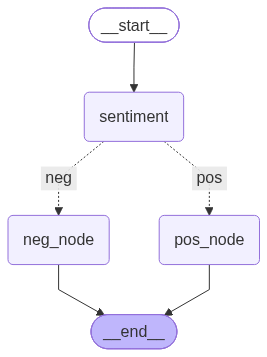

In [39]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())